# Deep Learning Pre-trained Model - Feature Extraction

- Alexnet
- VGG16
- ResNet18

In [3]:
import os
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg

In [23]:
from keras.applications.vgg16 import VGG16
from keras.applications.resnet50 import ResNet50
from keras.applications.densenet import DenseNet121

from keras.preprocessing import image
from keras.applications.vgg16 import preprocess_input as prepro_vgg16
from keras.applications.resnet50 import preprocess_input as prepro_resnet50
from keras.applications.densenet import preprocess_input as prepro_densenet121

### 0. Load Dataset Noised & Pure Dataset

In [8]:
labels = ['AF', 'N']

fs = 250

type_ = 'cnn' # pilih 'cnn' atau 'pure' untuk mengganti jenis data

In [9]:
dataset_folder = 'dataset/'
filenames = []
for filename in os.listdir(dataset_folder):
    if filename.find("_all") > -1 :
        filenames.append(filename)
        
filenames

['test_all.csv',
 'test_all_Conv_AE.csv',
 'train_all.csv',
 'train_all_Conv_AE.csv']

- read dataset

In [10]:
train_df = []
test_df = []

if type_ == 'cnn' :
    train_df = pd.read_csv(dataset_folder + "train_all_Conv_AE.csv", header=None)
    test_df = pd.read_csv(dataset_folder + "test_all_Conv_AE.csv", header=None)
elif type_ == 'pure' :
    train_df = pd.read_csv(dataset_folder + "train_all.csv", header=None)
    test_df = pd.read_csv(dataset_folder + "test_all.csv", header=None)

In [11]:
X_train=train_df.iloc[:,:600].values
X_test=test_df.iloc[:,:600].values

In [12]:
y_train=train_df.iloc[:,600].values
y_test=test_df.iloc[:,600].values

### 1. Convert Sequence to Image

In [13]:
def sequence_to_img(data):
    fig = Figure(figsize=(8, 8), dpi=28)
    canvas = FigureCanvasAgg(fig)

    ax = fig.add_subplot(111)
    ax.plot(data[0])
    ax.plot(data[1])
    ax.set_ylim(0,1)
    ax.axis('off')
    ax.margins(0)
    fig.tight_layout(pad=0)

    canvas.draw()
    buf = canvas.buffer_rgba()
    img = np.asarray(buf)[:, :, :3]
    return img

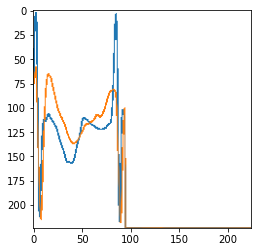

In [14]:
img = sequence_to_img(np.reshape(X_train[0], (2, 300)))
plt.imshow(img)

### 2. Feature Extraction - VGG16

- load VGG16 model

In [24]:
model_vgg16 = VGG16(weights='imagenet', include_top=False)

In [25]:
model_resnet50 = ResNet50(weights='imagenet', include_top=False)

In [27]:
model_densenet121 = DenseNet121(weights='imagenet', include_top=False)

In [29]:
def get_feature(name, img):
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    if name == 'vgg16' :
        x = prepro_vgg16(x)
        feature = model_vgg16.predict(x)
        return feature
    elif name == 'resnet50' :
        x = prepro_resnet50(x)
        feature = model_resnet50.predict(x)
        return feature
    elif name == 'densenet121' :
        x = prepro_densenet121(x)
        feature = model_densenet121.predict(x)
        return feature
    else :
        raise("%s model not found" % name)

- transform Train image to feature using VGG16

In [15]:
#vgg16_features = []
resnet50_features = []
densenet121_features = []

print("----- Feature Extraction for Train Dataset -------")
for i in range(len(X_train)):
    signal = np.reshape(X_train[i], (2, 300))
    img = sequence_to_img(signal)
    
    # calculate vgg16 feature     
#     vgg16_vec = get_feature('vgg16', img)
#     vgg16_features.append(vgg16_vec)
   
    # calculate resnet50 feature     
    resnet50_vec = get_feature('resnet50', img)
    resnet50_features.append(resnet50_vec)

    # calculate densenet121 feature     
    densenet121_vec = get_feature('densenet121', img)
    densenet121_features.append(densenet121_vec)
    
    if i % 500 == 0:
        tm = datetime.datetime.now().strftime("%H:%M:%S")
        print('[%s] - finish processing %d sample' % (tm, i))

----- Feature Extraction for Train Dataset -------
[08:16:19] - finish processing 0 sample
[08:18:27] - finish processing 500 sample
[08:20:42] - finish processing 1000 sample
[08:22:59] - finish processing 1500 sample
[08:25:22] - finish processing 2000 sample
[08:27:46] - finish processing 2500 sample
[08:30:13] - finish processing 3000 sample
[08:32:38] - finish processing 3500 sample
[08:35:03] - finish processing 4000 sample
[08:37:28] - finish processing 4500 sample
[08:39:54] - finish processing 5000 sample
[08:42:20] - finish processing 5500 sample
[08:44:45] - finish processing 6000 sample
[08:47:10] - finish processing 6500 sample
[08:49:36] - finish processing 7000 sample
[08:52:01] - finish processing 7500 sample
[08:54:27] - finish processing 8000 sample
[08:56:54] - finish processing 8500 sample
[08:59:21] - finish processing 9000 sample
[09:01:47] - finish processing 9500 sample
[09:04:13] - finish processing 10000 sample
[09:06:39] - finish processing 10500 sample
[09:0

- save feature extraction

In [26]:
np.savez_compressed('dataset/train_vgg16_feature', vgg16_feature=vgg16_features)

In [ ]:
np.savez_compressed('dataset/train_resnet50_feature', resnet50_feature=resnet50_features)

In [ ]:
np.savez_compressed('dataset/train_densenet121_feature', densenet121_feature=densenet121_features)

- transform Test image to feature using VGG16

In [30]:
vgg16_features = []
resnet50_features = []
densenet121_features = []

print("----- Feature Extraction for Test Dataset -------")
for i in range(len(X_test)):
    # transform data     
    signal = np.reshape(X_test[i], (2, 300))
    img = sequence_to_img(signal)
    
    # calculate vgg16 feature     
    vgg16_vec = get_feature('vgg16', img)
    vgg16_features.append(vgg16_vec)
   
    # calculate resnet50 feature     
    resnet50_vec = get_feature('resnet50', img)
    resnet50_features.append(resnet50_vec)

    # calculate densenet121 feature     
    densenet121_vec = get_feature('densenet121', img)
    densenet121_features.append(densenet121_vec)
    
    if i % 500 == 0:
        tm = datetime.datetime.now().strftime("%H:%M:%S")
        print('[%s] - finish processing %d sample' % (tm, i))

----- Feature Extraction for Test Dataset -------
[20:58:24] - finish processing 0 sample
[21:03:28] - finish processing 500 sample
[21:09:02] - finish processing 1000 sample
[21:14:42] - finish processing 1500 sample
[21:20:31] - finish processing 2000 sample
[21:26:22] - finish processing 2500 sample
[21:32:15] - finish processing 3000 sample
[21:38:14] - finish processing 3500 sample
[21:44:15] - finish processing 4000 sample
[21:50:16] - finish processing 4500 sample
[21:56:22] - finish processing 5000 sample
[22:02:31] - finish processing 5500 sample
[22:08:43] - finish processing 6000 sample
[22:15:11] - finish processing 6500 sample
[22:21:28] - finish processing 7000 sample
[22:28:02] - finish processing 7500 sample
[22:34:43] - finish processing 8000 sample
[22:41:04] - finish processing 8500 sample
[22:48:14] - finish processing 9000 sample
[22:55:17] - finish processing 9500 sample
[23:02:43] - finish processing 10000 sample
[23:09:21] - finish processing 10500 sample
[23:15

In [31]:
np.savez_compressed('dataset/test_vgg16_feature', vgg16_feature=vgg16_features)

In [32]:
np.savez_compressed('dataset/test_resnet50_feature', resnet50_feature=resnet50_features)

In [33]:
np.savez_compressed('dataset/test_densenet121_feature', densenet121_feature=densenet121_features)